In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:

# CELL 1 — CHECK GPU & PATHS  

import os, torch

print("=== GPU INFO ===")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    cap = torch.cuda.get_device_capability(0)
    print(f"CUDA capability: sm_{cap[0]}{cap[1]}")
    print(f"PyTorch version: {torch.__version__}")

print("\n=== DATASET PATHS ===")
BASE = "/kaggle/input/embryo_dataset"
for root, dirs, files in os.walk(BASE):
    dirs.sort(); files.sort()
    level = root.replace(BASE, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 1:
        for f in files[:3]:
            print(f"{indent}  {f}")
        if len(files) > 3:
            print(f"{indent}  ... ({len(files)} files total)")
    if level >= 2:
        dirs.clear()

=== GPU INFO ===
CUDA available : True
GPU name       : Tesla T4
VRAM           : 15.6 GB
CUDA capability: sm_75
PyTorch version: 2.10.0+cu128

=== DATASET PATHS ===


In [3]:
import subprocess, sys
 
for pkg in ["tqdm", "seaborn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
print("✅ Extra packages ready.")

✅ Extra packages ready.


In [4]:
import os, csv, glob, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import (
    mobilenet_v2,  MobileNet_V2_Weights,
    inception_v3,  Inception_V3_Weights,
    vgg16,         VGG16_Weights,
    vgg19,         VGG19_Weights,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm import tqdm
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True 
 
warnings.filterwarnings("ignore")
print("✅ All imports done.")

✅ All imports done.


In [31]:
# ── 16 development phases in strict biological order ─────────
PHASE_NAMES = [
    "pPB2",   # 0  Second polar body
    "pPNa",   # 1  Pro-nuclei appearance
    "pPNf",   # 2  Pro-nuclei disappearance
    "p2",     # 3  2 cells
    "p3",     # 4  3 cells
    "p4",     # 5  4 cells
    "p5",     # 6  5 cells
    "p6",     # 7  6 cells
    "p7",     # 8  7 cells
    "p8",     # 9  8 cells
    "p9+",    # 10 9+ cells
    "pM",     # 11 Morula / compaction
    "pSB",    # 12 Start blastulation
    "pB",     # 13 Full blastocyst
    "pEB",    # 14 Expanded blastocyst
    "pHB",    # 15 Hatched blastocyst
]
PHASE_TO_IDX = {p: i for i, p in enumerate(PHASE_NAMES)}
IDX_TO_PHASE = {i: p for p, i in PHASE_TO_IDX.items()}
NUM_CLASSES  = len(PHASE_NAMES)   # 16
 
# ── Paths  ────────────────────────────────────────────────────
INPUT_BASE      = "/kaggle/input/datasets/abhishekbuddiga06/embryo_dataset"
DATA_ROOT       = f"{INPUT_BASE}/embryo_dataset/embryo_dataset"
ANNOTATION_ROOT = f"{INPUT_BASE}/embryo_dataset_annotations/embryo_dataset_annotations"
WORK            = "/kaggle/working"
CHECKPOINT_DIR  = f"{WORK}/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Direct path verification ──────────────────────────────────
import os

INPUT_BASE      = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset"
DATA_ROOT       = f"{INPUT_BASE}/embryo_dataset/embryo_dataset"
ANNOTATION_ROOT = f"{INPUT_BASE}/embryo_dataset_annotations/embryo_dataset_annotations"

# Print character by character to catch hidden spaces
print(f"INPUT_BASE      = '{INPUT_BASE}'")
print(f"DATA_ROOT       = '{DATA_ROOT}'")
print(f"ANNOTATION_ROOT = '{ANNOTATION_ROOT}'")

# Check each level individually
levels = [
    "/kaggle/input",
    "/kaggle/input/datasets",
    "/kaggle/input/datasets/abhishekbuddiga06",
    "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset",
    "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset",
    "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset",
]

print("\n=== Level-by-level check ===")
for p in levels:
    exists = os.path.exists(p)
    print(f"  {'✅' if exists else '❌'}  {p}")
    if exists and os.path.isdir(p):
        children = os.listdir(p)
        print(f"       └─ {len(children)} items: {sorted(children)[:4]}")
 
# ── Hyper-parameters ──────────────────────────────────────────
SEED         = 42
BATCH_SIZE   = 64   # P100 16 GB VRAM — use 16 if OOM with VGG
NUM_EPOCHS   = 3
LR           = 1e-4
WEIGHT_DECAY = 1e-4
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15    # remaining 0.15 → test
 
# ── Custom-loss weights ───────────────────────────────────────
LABEL_SMOOTHING = 0.1
FOCAL_GAMMA     = 2.0
CE_WEIGHT       = 0.4   # must sum to 1.0
FOCAL_WEIGHT    = 0.4
ORDINAL_WEIGHT  = 0.2
 
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Config ready.  Device = {DEVICE}")
 
# Quick path check
print(f"\nDATA_ROOT exists       : {os.path.exists(DATA_ROOT)}")
print(f"ANNOTATION_ROOT exists : {os.path.exists(ANNOTATION_ROOT)}")
if os.path.exists(DATA_ROOT):
    embryo_list = [d for d in os.listdir(DATA_ROOT)
                   if os.path.isdir(os.path.join(DATA_ROOT, d))]
    print(f"Embryo folders found   : {len(embryo_list)}")
    print(f"Example IDs            : {sorted(embryo_list)[:5]}")
 

INPUT_BASE      = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset'
DATA_ROOT       = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset'
ANNOTATION_ROOT = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations'

=== Level-by-level check ===
  ✅  /kaggle/input
       └─ 1 items: ['datasets']
  ✅  /kaggle/input/datasets
       └─ 1 items: ['abhishekbuddiga06']
  ✅  /kaggle/input/datasets/abhishekbuddiga06
       └─ 1 items: ['embryo-dataset']
  ✅  /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset
       └─ 2 items: ['embryo_dataset', 'embryo_dataset_annotations']
  ✅  /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset
       └─ 1 items: ['embryo_dataset']
  ✅  /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset
       └─ 704 items: ['AA83-7', 'AAL839-6', 'AB028-6', 'AB91-1']
✅ Config ready.  Device = cuda

DATA_ROOT exists       

In [6]:
class EmbryoDataset(Dataset):
    """
    Maps every labeled JPEG frame → integer phase label.
 
    Annotation CSV format (tab OR comma separated, NO header):
        tPB2   7   22
        tPNa   23  99
        ...
    Event names use 't' prefix  (t2, tPB2 …);
    we convert to phase label   (p2, pPB2 …).
    """
 
    def __init__(self, embryo_ids, transform=None):
        self.transform = transform
        self.samples   = []   # [(jpeg_path, int_label), ...]
        skipped        = 0
 
        for eid in tqdm(embryo_ids, desc="Loading annotations", leave=False):
            ann_path = os.path.join(ANNOTATION_ROOT, f"{eid}_phases.csv")
            img_dir  = os.path.join(DATA_ROOT, eid)
 
            if not os.path.exists(ann_path) or not os.path.isdir(img_dir):
                skipped += 1
                continue
 
            # ── Parse CSV ─────────────────────────────────────
            frame_to_label = {}
            with open(ann_path) as f:
                content = f.read()
 
            delim = "\t" if "\t" in content else ","
            for line in content.strip().splitlines():
                parts = line.strip().split(delim)
                if len(parts) < 3:
                    continue
                event = parts[0].strip()
                # Convert  tXX  →  pXX
                phase = ("p" + event[1:]) if event.startswith("t") else event
                if phase not in PHASE_TO_IDX:
                    continue
                try:
                    s, e = int(parts[1].strip()), int(parts[2].strip())
                except ValueError:
                    continue
                label = PHASE_TO_IDX[phase]
                for fidx in range(s, e + 1):
                    frame_to_label[fidx] = label
 
            # ── Collect JPEG frames that have a label ──────────
            for jpg in sorted(glob.glob(os.path.join(img_dir, "*.jpeg"))):
                base   = os.path.splitext(os.path.basename(jpg))[0]
                if "RUN" in base:
                    run_part = base.split("RUN")[-1]   # "1", "10", "100"
                    digits   = "".join(filter(str.isdigit, run_part))
                else:
                    # fallback: take digits after last underscore
                    last_part = base.split("_")[-1]
                    digits    = "".join(filter(str.isdigit, last_part))

                if not digits:
                    continue
                fidx = int(digits)
                if fidx in frame_to_label:
                    self.samples.append((jpg, frame_to_label[fidx]))
 
        print(f"  → {len(self.samples):,} labeled frames | "
              f"{len(embryo_ids)-skipped}/{len(embryo_ids)} embryos OK"
              + (f" | {skipped} skipped" if skipped else ""))
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label
 
 
print("✅ EmbryoDataset defined.")
 

✅ EmbryoDataset defined.


In [45]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
 
def make_transform(img_size: int, is_train: bool):
    if is_train:
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ])
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])
 
 
def build_dataloaders(img_size: int = 224):
    """
    Split at the EMBRYO level (not frame level) to prevent data leakage.
    70% train / 15% val / 15% test
    Uses WeightedRandomSampler on training set to handle class imbalance.
    """
    all_ids = sorted([
        d for d in os.listdir(DATA_ROOT)
        if os.path.isdir(os.path.join(DATA_ROOT, d))
    ])
    random.shuffle(all_ids)
 
    n     = len(all_ids)
    n_tr  = int(n * TRAIN_SPLIT)
    n_val = int(n * VAL_SPLIT)
 
    train_ids = all_ids[:n_tr]
    val_ids   = all_ids[n_tr : n_tr + n_val]
    test_ids  = all_ids[n_tr + n_val :]
 
    print(f"\n📂 Embryo split  train:{len(train_ids)} | val:{len(val_ids)} | test:{len(test_ids)}")
 
    print("Building train dataset …")
    train_ds = EmbryoDataset(train_ids, make_transform(img_size, True))
    print("Building val dataset …")
    val_ds   = EmbryoDataset(val_ids,   make_transform(img_size, False))
    print("Building test dataset …")
    test_ds  = EmbryoDataset(test_ids,  make_transform(img_size, False))
 
    # ── Weighted sampler ──────────────────────────────────────
    labels        = [s[1] for s in train_ds.samples]
    class_counts  = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_w      = [class_weights[l] for l in labels]
    sampler       = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
 
    # P100 has fast PCIe — num_workers=4 works well
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=4, pin_memory=True,persistent_workers=True)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)
 
    print(f"\n📊 Class distribution in training set:")
    for name, cnt in zip(PHASE_NAMES, class_counts):
        bar = "█" * int(cnt / max(class_counts) * 30)
        print(f"  {name:6s} {int(cnt):>7,}  {bar}")
 
    return train_dl, val_dl, test_dl, class_counts
 
 
# Build 224×224 loaders (InceptionV3 will rebuild at 299×299)
print("\nBuilding default data loaders (224×224) …")
train_loader, val_loader, test_loader, class_counts = build_dataloaders(224)
print("\n✅ Data loaders ready.")


Building default data loaders (224×224) …

📂 Embryo split  train:492 | val:105 | test:107
Building train dataset …


  → 209,566 labeled frames | 492/492 embryos OK
Building val dataset …


  → 44,777 labeled frames | 105/105 embryos OK
Building test dataset …


  → 43,085 labeled frames | 107/107 embryos OK

📊 Class distribution in training set:
  pPB2     6,195  █████
  pPNa    30,396  █████████████████████████
  pPNf     4,689  ███
  p2      20,582  █████████████████
  p3       3,350  ██
  p4      20,662  █████████████████
  p5       5,453  ████
  p6       5,779  ████
  p7       6,853  █████
  p8      23,041  ███████████████████
  p9+     36,095  ██████████████████████████████
  pM      12,172  ██████████
  pSB     12,577  ██████████
  pB       7,195  █████
  pEB     14,433  ███████████
  pHB         94  

✅ Data loaders ready.


In [46]:
class EmbryoStageLoss(nn.Module):
 
    def __init__(
        self,
        num_classes     = NUM_CLASSES,
        label_smoothing = LABEL_SMOOTHING,
        focal_gamma     = FOCAL_GAMMA,
        ce_weight       = CE_WEIGHT,
        focal_weight    = FOCAL_WEIGHT,
        ordinal_weight  = ORDINAL_WEIGHT,
        class_weights   = None,          # optional (K,) tensor
    ):
        super().__init__()
        self.K     = num_classes
        self.eps   = label_smoothing
        self.gamma = focal_gamma
        self.w_ce  = ce_weight
        self.w_foc = focal_weight
        self.w_ord = ordinal_weight
        self.cw    = class_weights
 
        # Normalised ordinal distance matrix  D[i,j] = |i-j| / (K-1)
        idx = torch.arange(num_classes, dtype=torch.float32)
        D   = (idx.unsqueeze(0) - idx.unsqueeze(1)).abs() / (num_classes - 1)
        self.register_buffer("ordinal_dist", D)   # (K, K)
 
    def forward(self, logits, targets):
        # logits  : (B, K)   targets : (B,)
        log_p = F.log_softmax(logits, dim=1)
        p     = log_p.exp()
 
        # ── 1. Label-smoothed CE ──────────────────────────────
        smooth = torch.full_like(log_p, self.eps / self.K)
        smooth.scatter_(1, targets.unsqueeze(1),
                        1.0 - self.eps + self.eps / self.K)
        l_ce = -(smooth * log_p).sum(dim=1)                   # (B,)
 
        # ── 2. Focal weighting ────────────────────────────────
        p_t     = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        l_focal = (1.0 - p_t).pow(self.gamma) * l_ce         # (B,)
 
        # ── 3. Ordinal penalty ────────────────────────────────
        l_ord = (p * self.ordinal_dist[targets]).sum(dim=1)   # (B,)
 
        # ── Optional per-class sample weights ─────────────────
        if self.cw is not None:
            w       = self.cw.to(targets.device)[targets]
            l_ce    = l_ce    * w
            l_focal = l_focal * w
            l_ord   = l_ord   * w
 
        return (self.w_ce  * l_ce.mean()  +
                self.w_foc * l_focal.mean() +
                self.w_ord * l_ord.mean())
 
 
print("✅ EmbryoStageLoss defined.")

✅ EmbryoStageLoss defined.


In [47]:
def build_model(arch: str, num_classes: int = NUM_CLASSES) -> nn.Module:
    """
    Load ImageNet pretrained weights and replace the final head.
    Fine-tuning a pretrained backbone on medical images converges
    faster and achieves higher accuracy than training from scratch.
    """
    arch = arch.lower()
 
    if arch == "mobilenetv2":
        m = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
 
    elif arch == "inceptionv3":
        # Needs 299×299.  Has auxiliary classifier for deeper gradients.
        m = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        m.fc              = nn.Linear(m.fc.in_features, num_classes)
        m.AuxLogits.fc    = nn.Linear(m.AuxLogits.fc.in_features, num_classes)
 
    elif arch == "vgg16":
        m = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
 
    elif arch == "vgg19":
        m = vgg19(weights=VGG19_Weights.IMAGENET1K_V1)
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    
    # Freeze all feature layers — only train classifier
        for param in m.features.parameters():
            param.requires_grad = False
    # Unfreeze last 4 conv layers only
        for layer in list(m.features.children())[-8:]:
            for param in layer.parameters():
                param.requires_grad = True
 
    else:
        raise ValueError(f"Unknown arch '{arch}'. "
                         "Choose: mobilenetv2 | inceptionv3 | vgg16 | vgg19")
 
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {arch.upper():14s}  total={total:>12,}  trainable={trainable:>12,}")
    return m.to(DEVICE)
 
 
print("✅ build_model defined.")

✅ build_model defined.


In [48]:

# CELL 9 — TRAINING & EVALUATION HELPERS

 
class EarlyStopping:
    def __init__(self, patience=6, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.best      = float("inf")
        self.counter   = 0
        self.stop      = False
 
    def step(self, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best    = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
 
 
def train_one_epoch(model, loader, criterion, optimizer, arch):
    model.train()
    total_loss = correct = total = 0
 
    for imgs, labels in tqdm(loader, desc="  train", leave=False):
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
 
        if arch == "inceptionv3":
            out, aux = model(imgs)
            loss = criterion(out, labels) + 0.4 * criterion(aux, labels)
        else:
            out  = model(imgs)
            loss = criterion(out, labels)
 
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
 
        bs          = imgs.size(0)
        total_loss += loss.item() * bs
        correct    += (out.argmax(1) == labels).sum().item()
        total      += bs
 
    return total_loss / total, correct / total
 
 
@torch.no_grad()
def evaluate(model, loader, criterion, arch):
    model.eval()
    total_loss = correct = total = 0
    all_preds  = []
    all_labels = []
 
    for imgs, labels in tqdm(loader, desc="  eval ", leave=False):
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
 
        out = model(imgs)
        if isinstance(out, tuple):
            out = out[0]   # InceptionV3 eval sometimes returns tuple
 
        loss        = criterion(out, labels)
        bs          = imgs.size(0)
        total_loss += loss.item() * bs
        preds       = out.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += bs
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
 
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels))
 
 
def save_ckpt(model, optimizer, epoch, val_loss, arch):
    path = os.path.join(CHECKPOINT_DIR, f"{arch}_best.pt")
    torch.save({
        "epoch":     epoch,
        "model":     model.state_dict(),
        "optim":     optimizer.state_dict(),
        "val_loss":  val_loss,
    }, path)
    print(f"  💾 Checkpoint saved → {path}")
 
 
def load_ckpt(model, arch):
    path = os.path.join(CHECKPOINT_DIR, f"{arch}_best.pt")
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ckpt["model"])
        print(f"  📂 Loaded best ckpt  epoch={ckpt['epoch']}  "
              f"val_loss={ckpt['val_loss']:.4f}")
    return model
 
 
print("✅ Training helpers defined.")
 

✅ Training helpers defined.


In [49]:
def train_architecture(arch: str, tr_dl, vl_dl, cls_counts):
    """
    Full pipeline for one architecture:
      • AdamW optimizer  (decoupled weight decay)
      • CosineAnnealingLR  (smooth decay, no sharp drops)
      • EarlyStopping on val loss  (patience = 6)
      • Best checkpoint saved automatically
    """
    sep = "━" * 58
    print(f"\n{sep}\n  🚀  {arch.upper()}\n{sep}")
 
    model = build_model(arch)
 
    # Per-class inverse-frequency weights for the loss
    cw   = 1.0 / (cls_counts + 1e-6)
    cw   = (cw / cw.sum() * NUM_CLASSES).astype(np.float32)
    cw_t = torch.tensor(cw).to(DEVICE)
 
    criterion = EmbryoStageLoss(class_weights=cw_t).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
    )
    stopper   = EarlyStopping(patience=6)
    history   = {"tr_loss": [], "vl_loss": [], "tr_acc": [], "vl_acc": []}
    best_vl   = float("inf")
 
    for epoch in range(1, NUM_EPOCHS + 1):
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"\n  Epoch {epoch:02d}/{NUM_EPOCHS}   lr={lr_now:.2e}")
 
        tr_loss, tr_acc            = train_one_epoch(model, tr_dl, criterion, optimizer, arch)
        vl_loss, vl_acc, _, _     = evaluate(model, vl_dl, criterion, arch)
        scheduler.step()
 
        history["tr_loss"].append(tr_loss)
        history["vl_loss"].append(vl_loss)
        history["tr_acc"].append(tr_acc)
        history["vl_acc"].append(vl_acc)
 
        print(f"    Train → loss={tr_loss:.4f}  acc={tr_acc*100:.2f}%")
        print(f"    Val   → loss={vl_loss:.4f}  acc={vl_acc*100:.2f}%")
 
        if vl_loss < best_vl:
            best_vl = vl_loss
            save_ckpt(model, optimizer, epoch, vl_loss, arch)
 
        stopper.step(vl_loss)
        if stopper.stop:
            print(f"  ⛔ Early stopping triggered at epoch {epoch}.")
            break
 
    return model, history, criterion
 
 
print("✅ train_architecture defined.")
 

✅ train_architecture defined.


In [50]:

# CELL 11 — VISUALISATION HELPERS

 
def plot_curves(history, arch):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Training Curves — {arch.upper()}", fontsize=13, fontweight="bold")
 
    ax = axes[0]
    ax.plot(history["tr_loss"], "b-o", ms=3, label="Train")
    ax.plot(history["vl_loss"], "r-o", ms=3, label="Val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Loss"); ax.legend(); ax.grid(alpha=0.3)
 
    ax = axes[1]
    ax.plot([a*100 for a in history["tr_acc"]], "b-o", ms=3, label="Train")
    ax.plot([a*100 for a in history["vl_acc"]], "r-o", ms=3, label="Val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy"); ax.legend(); ax.grid(alpha=0.3)
 
    plt.tight_layout()
    out = f"{WORK}/{arch}_curves.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  💾 {out}")
 
 
def plot_cm(y_true, y_pred, arch):
    # NEW
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(16, 13))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd",
                xticklabels=PHASE_NAMES, yticklabels=PHASE_NAMES,
                linewidths=0.4, ax=ax)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)
    ax.set_title(f"Confusion Matrix — {arch.upper()}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out = f"{WORK}/{arch}_cm.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  💾 {out}")
 
 
def test_and_report(model, ts_dl, criterion, arch):
    print(f"\n{'━'*58}")
    print(f"  🧪  Test Evaluation — {arch.upper()}")
    print(f"{'━'*58}")
 
    model = load_ckpt(model, arch)
    ts_loss, ts_acc, preds, labels = evaluate(model, ts_dl, criterion, arch)
 
    print(f"\n  Test loss     : {ts_loss:.4f}")
    print(f"  Test accuracy : {ts_acc*100:.2f}%")
    print(f"\n  Per-class report:")
    # NEW
    all_label_indices = list(range(NUM_CLASSES))

    print(classification_report(labels, preds,
                            labels=all_label_indices,
                            target_names=PHASE_NAMES,
                            zero_division=0))

    f1m = f1_score(labels, preds, labels=all_label_indices, average="macro",    zero_division=0)
    f1w = f1_score(labels, preds, labels=all_label_indices, average="weighted", zero_division=0)
    print(f"  Macro F1    : {f1m:.4f}")
    print(f"  Weighted F1 : {f1w:.4f}")
 
    plot_cm(labels, preds, arch)
 
    return {
        "arch":        arch,
        "test_loss":   ts_loss,
        "test_acc":    ts_acc,
        "f1_macro":    f1m,
        "f1_weighted": f1w,
    }
 
 
print("✅ Visualisation helpers defined.")
 

✅ Visualisation helpers defined.


🔄 Recovering previously trained models...

--- Recovering MobileNetV2 ---
  MOBILENETV2     total=   2,244,368  trainable=   2,244,368

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🧪  Test Evaluation — MOBILENETV2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



  Test loss     : 0.2176
  Test accuracy : 9.49%

  Per-class report:
              precision    recall  f1-score   support

        pPB2       0.00      0.00      0.00      1355
        pPNa       0.07      0.12      0.09      6464
        pPNf       0.00      0.00      0.00      1114
          p2       0.21      0.00      0.00      4192
          p3       0.00      0.00      0.00      1079
          p4       0.05      0.02      0.03      4167
          p5       0.00      0.00      0.00      1492
          p6       0.00      0.00      0.00      1115
          p7       0.00      0.00      0.00      1535
          p8       0.00      0.00      0.00      4664
         p9+       0.16      0.42      0.23      7613
          pM       0.00      0.00      0.00      2276
         pSB       0.00      0.00      0.00      2135
          pB       0.00      0.00      0.00      1571
         pEB       0.00      0.00      0.00      2310
         pHB       0.00      0.00      0.00         3

    accur

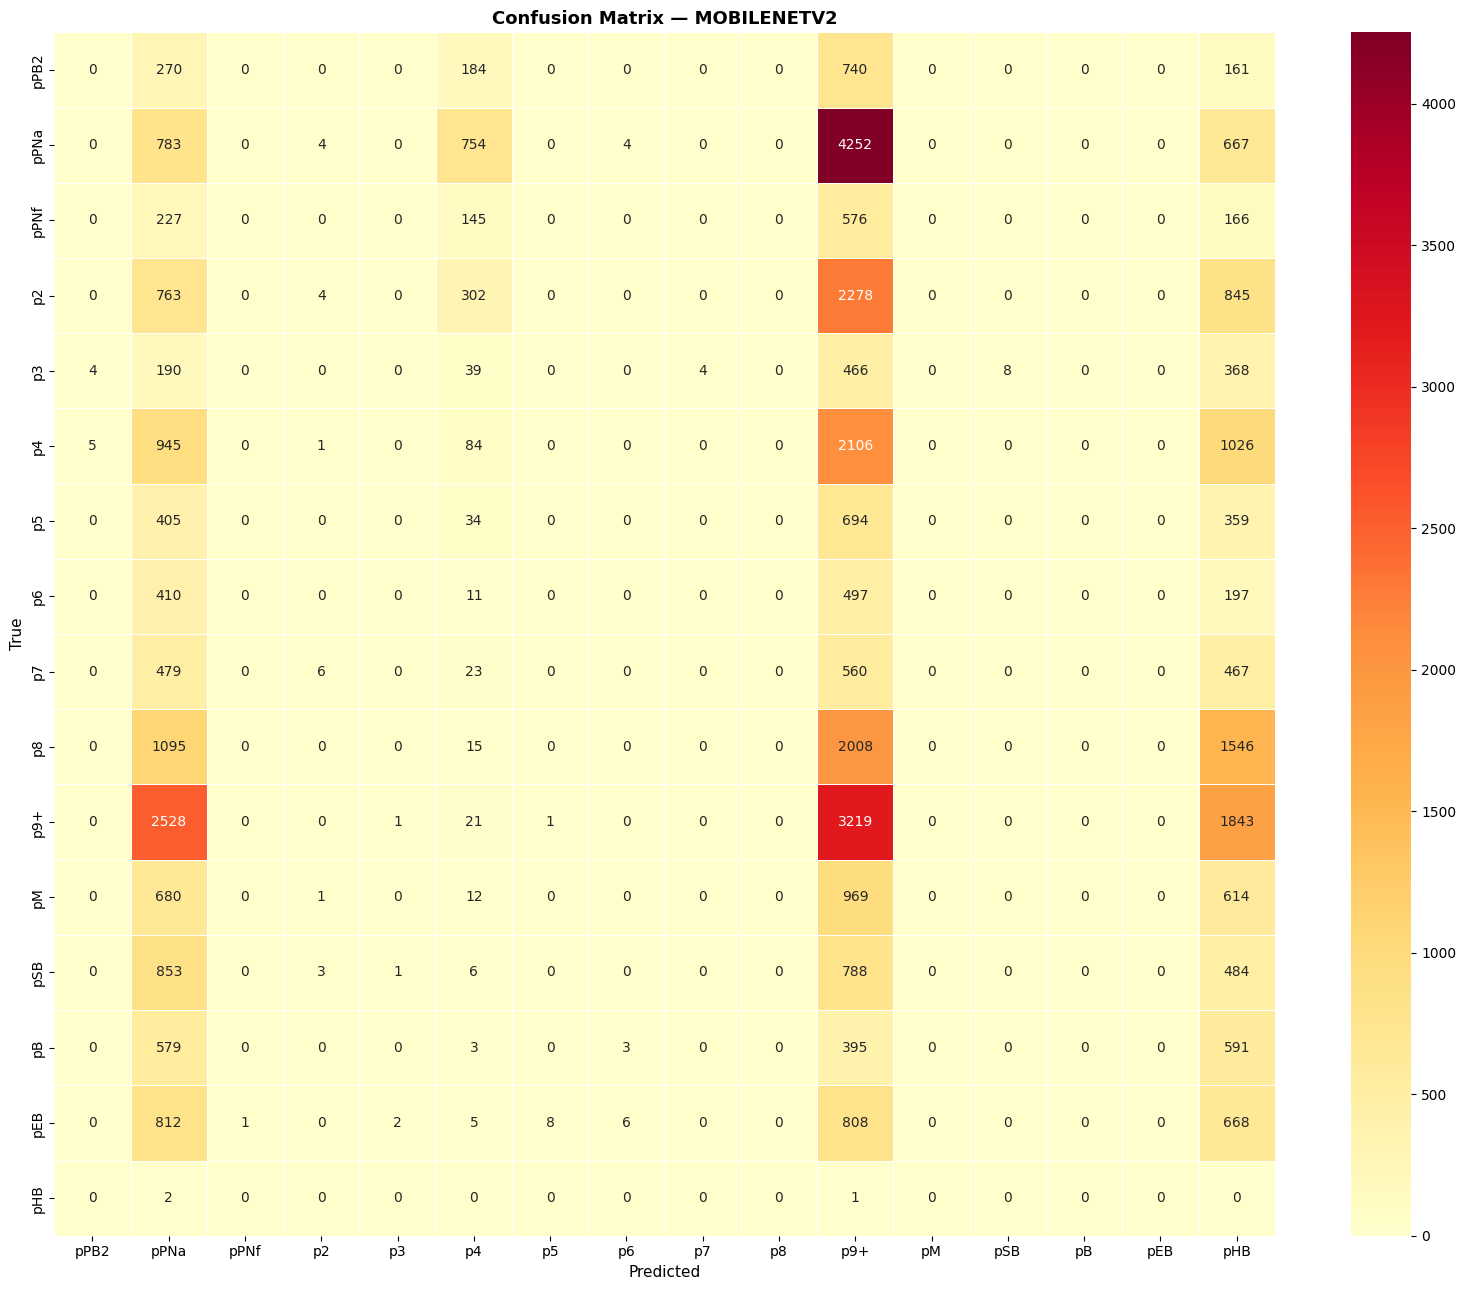

  💾 /kaggle/working/mobilenetv2_cm.png

--- Recovering VGG-16 ---
  VGG16           total= 134,326,096  trainable= 134,326,096

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🧪  Test Evaluation — VGG16
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



  Test loss     : 0.2153
  Test accuracy : 4.69%

  Per-class report:
              precision    recall  f1-score   support

        pPB2       0.03      0.16      0.05      1355
        pPNa       0.00      0.00      0.00      6464
        pPNf       0.00      0.00      0.00      1114
          p2       0.09      0.02      0.03      4192
          p3       0.04      0.09      0.06      1079
          p4       0.00      0.00      0.00      4167
          p5       0.00      0.00      0.00      1492
          p6       0.02      0.03      0.02      1115
          p7       0.05      0.01      0.02      1535
          p8       1.00      0.00      0.00      4664
         p9+       0.00      0.00      0.00      7613
          pM       0.06      0.69      0.11      2276
         pSB       0.00      0.00      0.00      2135
          pB       0.00      0.00      0.00      1571
         pEB       0.00      0.00      0.00      2310
         pHB       0.00      1.00      0.00         3

    accur

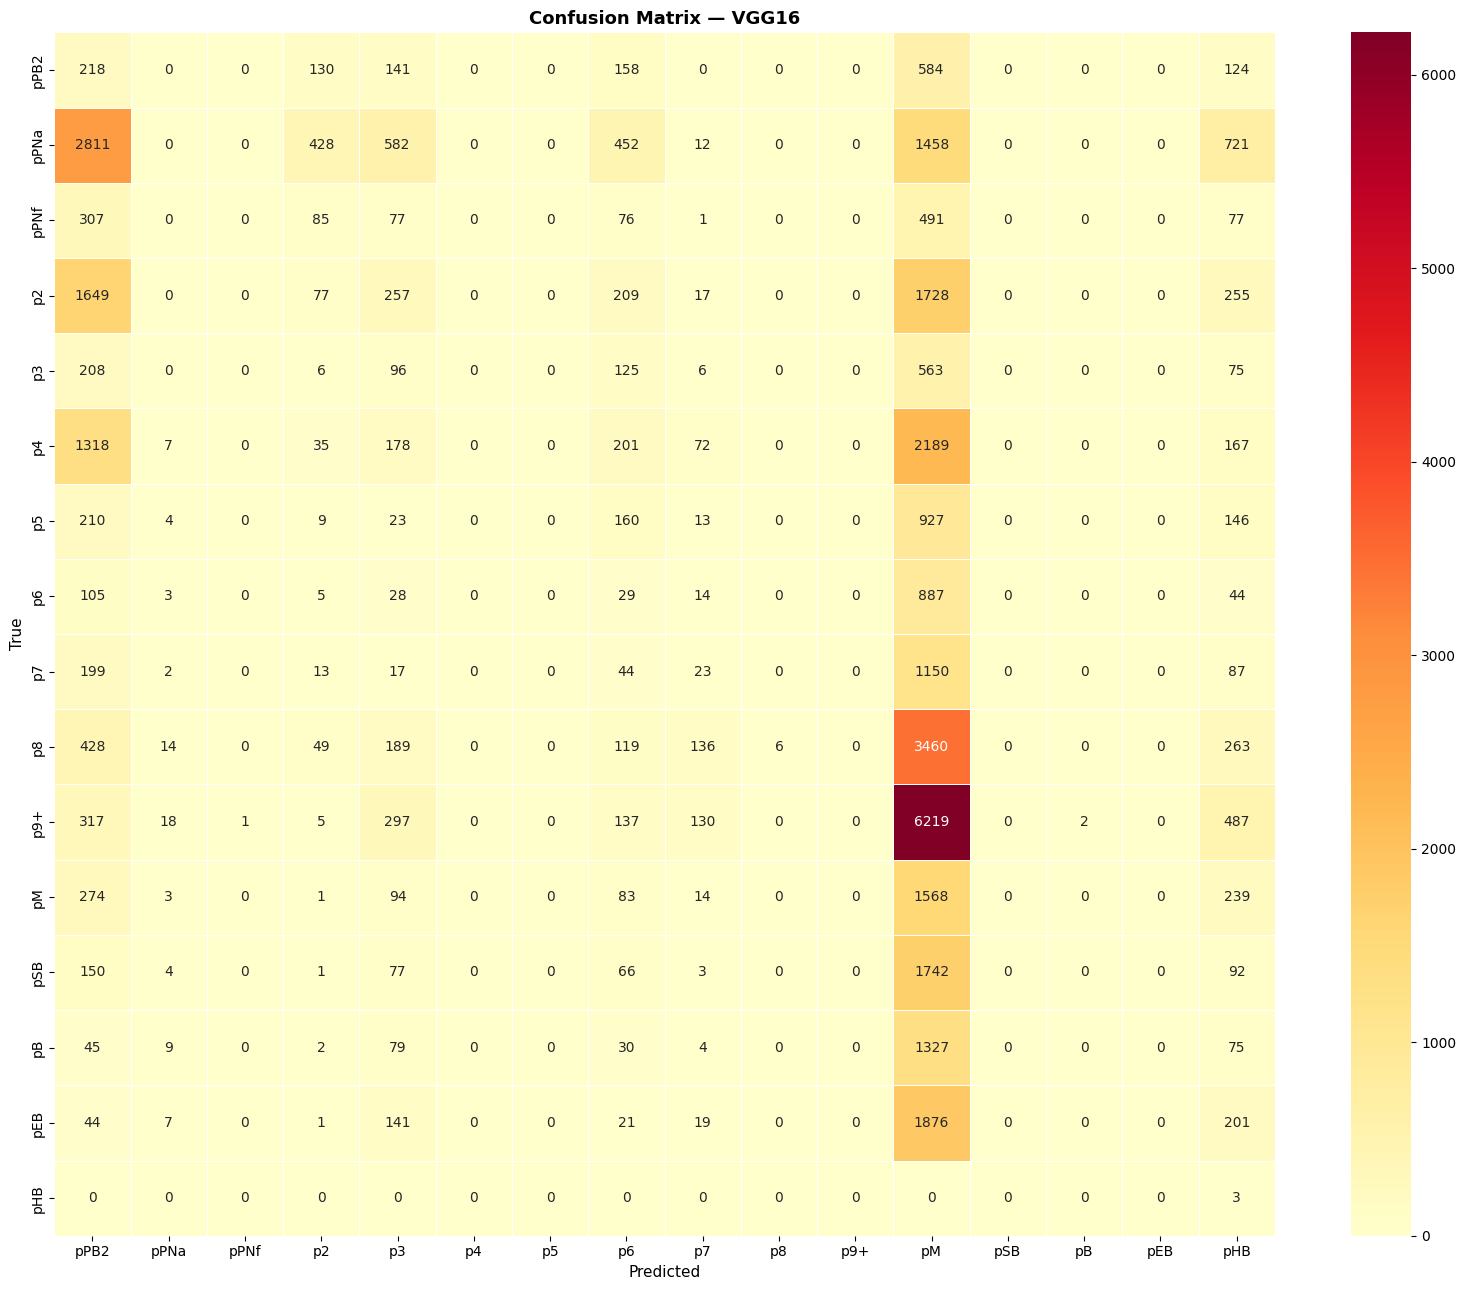

  💾 /kaggle/working/vgg16_cm.png

✅ Recovery complete! You can now move on to VGG-19.


In [55]:

# RECOVERY CELL — LOAD FINISHED MODELS FROM HARD DRIVE

print("🔄 Recovering previously trained models...")
all_results = []

# Re-create the loss criterion (needed for testing)
cw = 1.0 / (class_counts + 1e-6)
cw = (cw / cw.sum() * NUM_CLASSES).astype(np.float32)
cw_t = torch.tensor(cw).to(DEVICE)
criterion = EmbryoStageLoss(class_weights=cw_t).to(DEVICE)

# 1. Recover MobileNetV2
print("\n--- Recovering MobileNetV2 ---")
m_mb = build_model("mobilenetv2")
# test_and_report automatically loads the saved .pt file!
all_results.append(test_and_report(m_mb, test_loader, criterion, "mobilenetv2"))
del m_mb; torch.cuda.empty_cache()

# 2. Recover VGG-16
print("\n--- Recovering VGG-16 ---")
m_vgg16 = build_model("vgg16")
all_results.append(test_and_report(m_vgg16, test_loader, criterion, "vgg16"))
del m_vgg16; torch.cuda.empty_cache()

print("\n✅ Recovery complete! You can now move on to VGG-19.")

In [14]:

# CELL 12 — RUN MOBILENETV2   (~1–2 h on P100)

 
all_results = []
 
m, h, c = train_architecture("mobilenetv2", train_loader, val_loader, class_counts)
plot_curves(h, "mobilenetv2")
all_results.append(test_and_report(m, test_loader, c, "mobilenetv2"))
del m; torch.cuda.empty_cache()
print("✅ MobileNetV2 done.")

In [15]:
m, h, c = train_architecture("vgg16", train_loader, val_loader, class_counts)
plot_curves(h, "vgg16")
all_results.append(test_and_report(m, test_loader, c, "vgg16"))
del m; torch.cuda.empty_cache()
print("✅ VGG-16 done.")

In [52]:

# RESTORE all_results FROM COMPLETED MODELS

all_results = []

# Load and evaluate already completed models
for arch in ["mobilenetv2", "vgg16", "vgg19"]:
    ckpt_path = f"{CHECKPOINT_DIR}/{arch}_best.pt"
    if os.path.exists(ckpt_path):
        print(f"✅ Found checkpoint for {arch.upper()} — loading...")
        
        # Build model and load checkpoint
        m_temp = build_model(arch)
        m_temp = load_ckpt(m_temp, arch)
        
        # Rebuild loss
        cw   = 1.0 / (class_counts + 1e-6)
        cw   = (cw / cw.sum() * NUM_CLASSES).astype(np.float32)
        cw_t = torch.tensor(cw).to(DEVICE)
        c_temp = EmbryoStageLoss(class_weights=cw_t)
        
        # Evaluate on test set
        result = test_and_report(m_temp, test_loader, c_temp, arch)
        all_results.append(result)
        
        del m_temp
        torch.cuda.empty_cache()
    else:
        print(f"❌ No checkpoint found for {arch.upper()} — skipping")

print(f"\n✅ all_results restored with {len(all_results)} models")
print(f"   Models loaded: {[r['arch'] for r in all_results]}")

❌ No checkpoint found for MOBILENETV2 — skipping
❌ No checkpoint found for VGG16 — skipping
❌ No checkpoint found for VGG19 — skipping

✅ all_results restored with 0 models
   Models loaded: []



--- Recovering VGG-19 ---
  VGG19           total= 139,635,792  trainable= 126,690,832

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🧪  Test Evaluation — VGG19
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📂 Loaded best ckpt  epoch=3  val_loss=0.1264



  Test loss     : 0.1314
  Test accuracy : 37.74%

  Per-class report:
              precision    recall  f1-score   support

        pPB2       0.35      0.79      0.49      1355
        pPNa       0.98      0.52      0.68      6464
        pPNf       0.31      0.63      0.42      1114
          p2       0.74      0.34      0.46      4192
          p3       0.14      0.54      0.22      1079
          p4       0.52      0.30      0.38      4167
          p5       0.16      0.27      0.21      1492
          p6       0.09      0.24      0.13      1115
          p7       0.12      0.28      0.17      1535
          p8       0.30      0.14      0.19      4664
         p9+       0.90      0.21      0.33      7613
          pM       0.30      0.59      0.40      2276
         pSB       0.31      0.69      0.43      2135
          pB       0.41      0.42      0.41      1571
         pEB       0.52      0.49      0.50      2310
         pHB       1.00      0.67      0.80         3

    accu

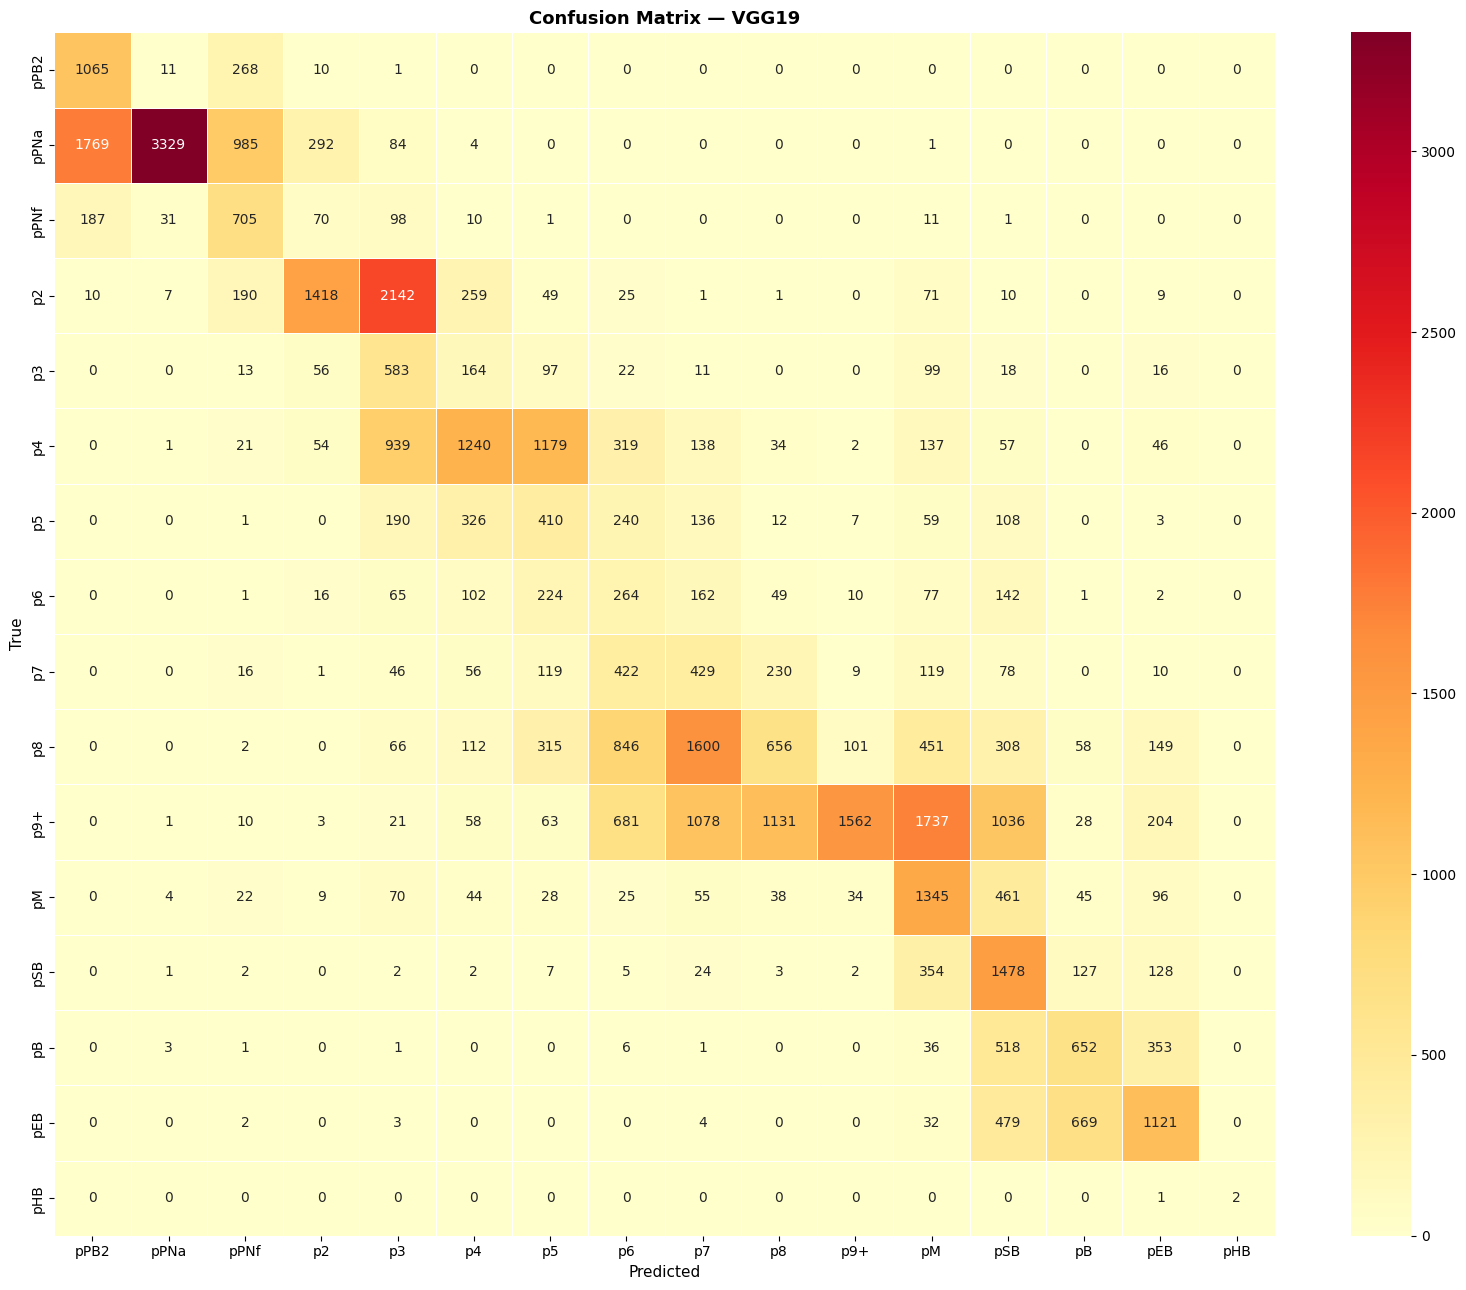

  💾 /kaggle/working/vgg19_cm.png

--- Recovering InceptionV3 ---
♻ Rebuilding data loaders at 299x299 for InceptionV3 ...

📂 Embryo split  train:492 | val:105 | test:107
Building train dataset …


  → 209,279 labeled frames | 492/492 embryos OK
Building val dataset …


  → 43,025 labeled frames | 105/105 embryos OK
Building test dataset …


  → 45,124 labeled frames | 107/107 embryos OK

📊 Class distribution in training set:
  pPB2     6,206  █████
  pPNa    30,390  █████████████████████████
  pPNf     4,794  ███
  p2      20,489  ████████████████
  p3       3,910  ███
  p4      20,176  ████████████████
  p5       5,859  ████
  p6       6,403  █████
  p7       6,957  █████
  p8      21,786  ██████████████████
  p9+     36,163  ██████████████████████████████
  pM      12,175  ██████████
  pSB     12,372  ██████████
  pB       7,386  ██████
  pEB     14,203  ███████████
  pHB         10  
  INCEPTIONV3     total=  24,388,352  trainable=  24,388,352

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🧪  Test Evaluation — INCEPTIONV3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📂 Loaded best ckpt  epoch=2  val_loss=0.1196



  Test loss     : 0.0709
  Test accuracy : 68.81%

  Per-class report:
              precision    recall  f1-score   support

        pPB2       0.67      0.89      0.77      1371
        pPNa       0.98      0.81      0.89      6279
        pPNf       0.56      0.83      0.67      1060
          p2       0.90      0.71      0.79      4338
          p3       0.31      0.71      0.43       621
          p4       0.83      0.51      0.63      4554
          p5       0.29      0.78      0.42      1195
          p6       0.44      0.66      0.53       947
          p7       0.62      0.61      0.61      2017
          p8       0.70      0.63      0.66      5496
         p9+       0.79      0.60      0.68      7728
          pM       0.51      0.80      0.62      2714
         pSB       0.61      0.75      0.67      2630
          pB       0.62      0.70      0.66      1507
         pEB       0.87      0.73      0.79      2665
         pHB       0.15      1.00      0.27         2

    accu

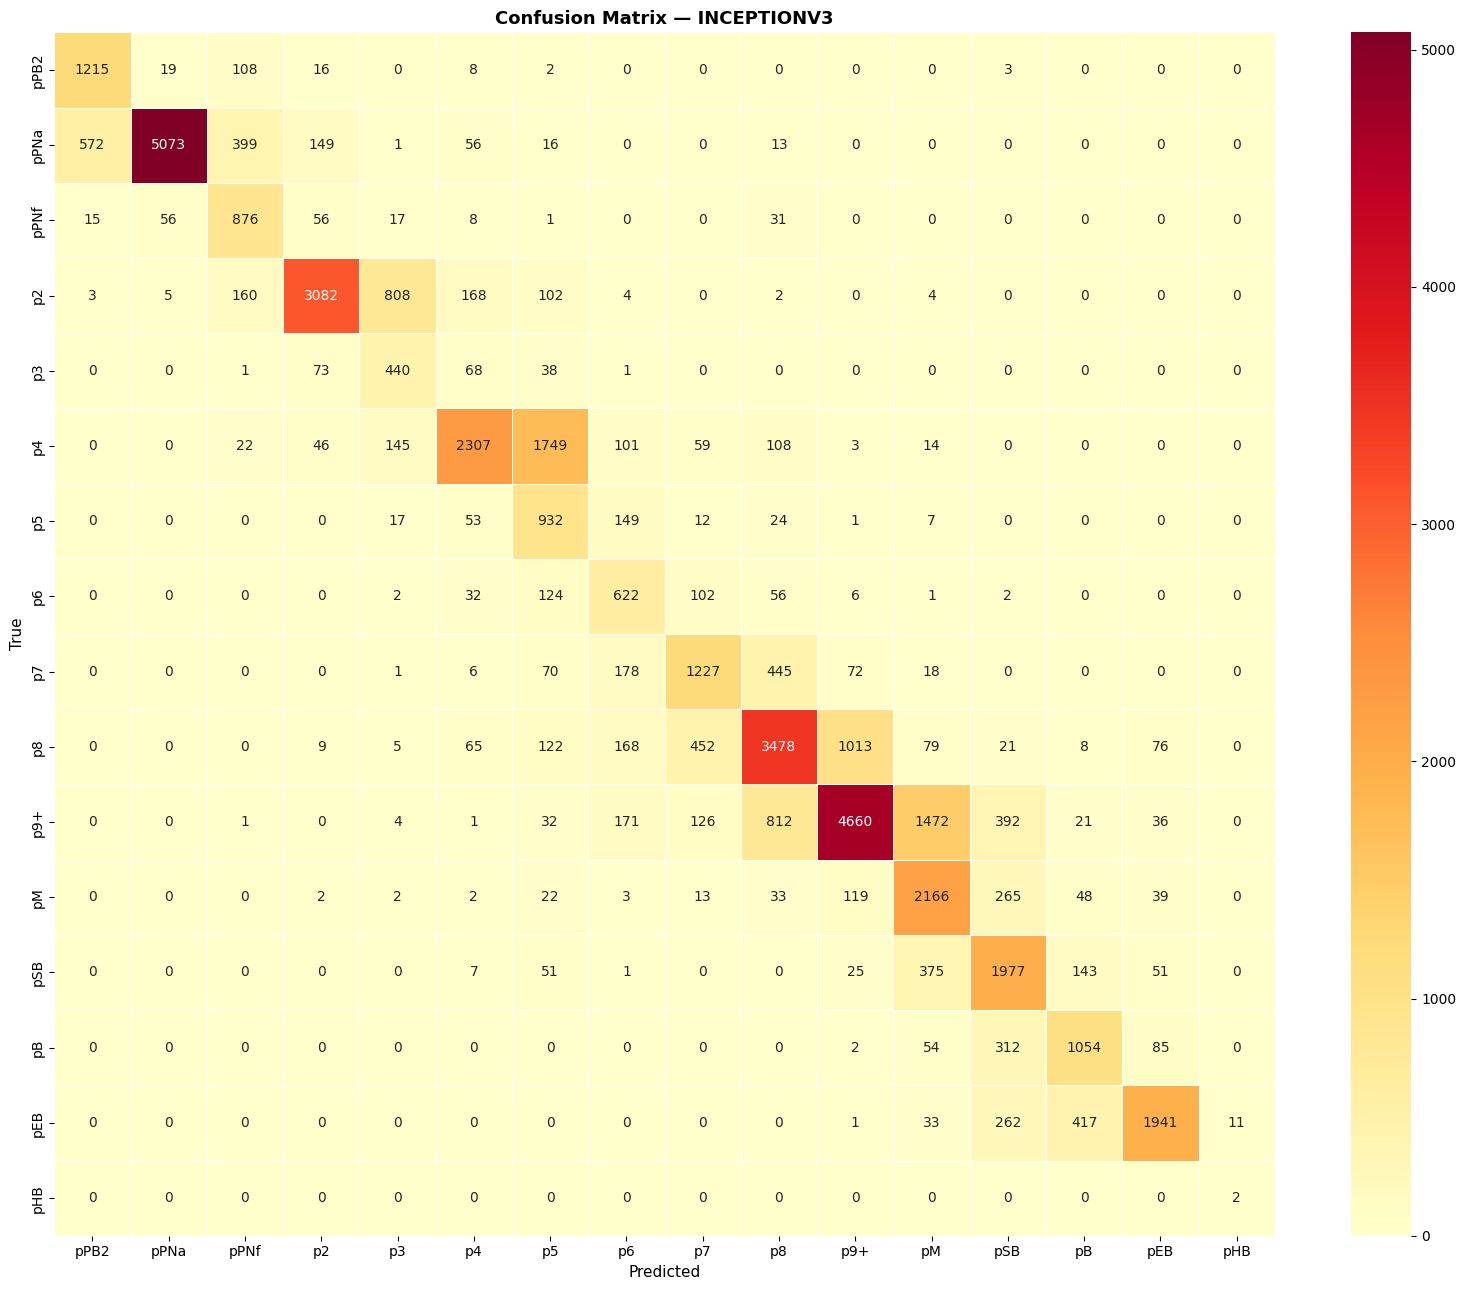

  💾 /kaggle/working/inceptionv3_cm.png
✅ Recovery complete! You can now run Cell 16 to generate your final comparison chart.


In [57]:
# ============================================================
# RECOVER VGG-19 & INCEPTIONV3 FROM HARD DRIVE
# ============================================================
print("\n--- Recovering VGG-19 ---")
# 1. Recover VGG-19 using the standard 224x224 test_loader
m_vgg19 = build_model("vgg19")
all_results.append(test_and_report(m_vgg19, test_loader, criterion, "vgg19"))
del m_vgg19
torch.cuda.empty_cache()

print("\n--- Recovering InceptionV3 ---")
# 2. Rebuild data loaders at 299x299 specifically for InceptionV3
print("♻ Rebuilding data loaders at 299x299 for InceptionV3 ...")
_, _, ts299, _ = build_dataloaders(img_size=299)

# 3. Recover InceptionV3 using the new ts299 loader
m_inc3 = build_model("inceptionv3")
all_results.append(test_and_report(m_inc3, ts299, criterion, "inceptionv3"))
del m_inc3
torch.cuda.empty_cache()

print("✅ Recovery complete! You can now run Cell 16 to generate your final comparison chart.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🚀  VGG19
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VGG19           total= 139,635,792  trainable= 126,690,832

  Epoch 01/3   lr=1.00e-04


    Train → loss=0.3459  acc=49.93%
    Val   → loss=0.1301  acc=30.30%
  💾 Checkpoint saved → /kaggle/working/checkpoints/vgg19_best.pt

  Epoch 02/3   lr=7.52e-05


    Train → loss=0.3044  acc=63.75%
    Val   → loss=0.1284  acc=32.89%
  💾 Checkpoint saved → /kaggle/working/checkpoints/vgg19_best.pt

  Epoch 03/3   lr=2.58e-05


    Train → loss=0.2871  acc=71.05%
    Val   → loss=0.1264  acc=37.46%
  💾 Checkpoint saved → /kaggle/working/checkpoints/vgg19_best.pt


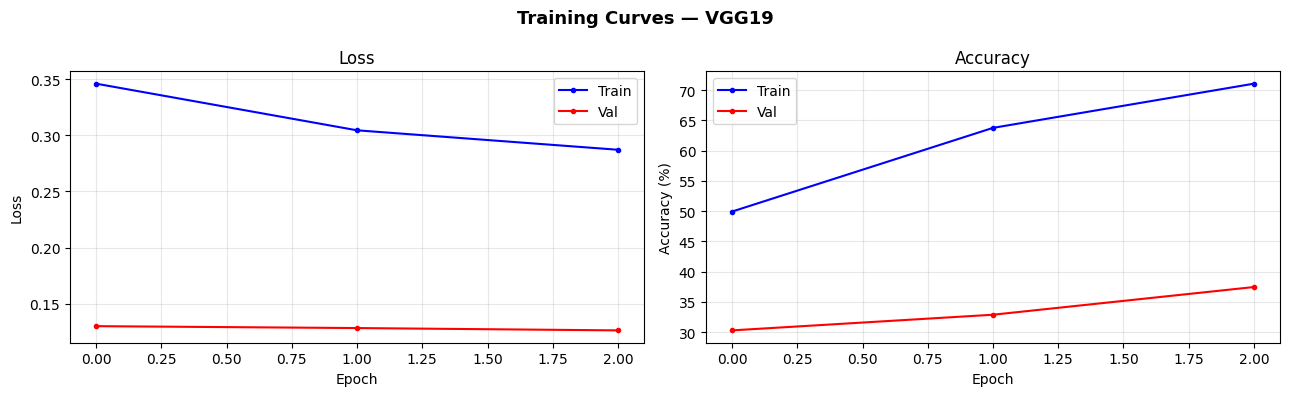

  💾 /kaggle/working/vgg19_curves.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🧪  Test Evaluation — VGG19
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📂 Loaded best ckpt  epoch=3  val_loss=0.1264



  Test loss     : 0.1314
  Test accuracy : 37.74%

  Per-class report:
              precision    recall  f1-score   support

        pPB2       0.35      0.79      0.49      1355
        pPNa       0.98      0.52      0.68      6464
        pPNf       0.31      0.63      0.42      1114
          p2       0.74      0.34      0.46      4192
          p3       0.14      0.54      0.22      1079
          p4       0.52      0.30      0.38      4167
          p5       0.16      0.27      0.21      1492
          p6       0.09      0.24      0.13      1115
          p7       0.12      0.28      0.17      1535
          p8       0.30      0.14      0.19      4664
         p9+       0.90      0.21      0.33      7613
          pM       0.30      0.59      0.40      2276
         pSB       0.31      0.69      0.43      2135
          pB       0.41      0.42      0.41      1571
         pEB       0.52      0.49      0.50      2310
         pHB       1.00      0.67      0.80         3

    accu

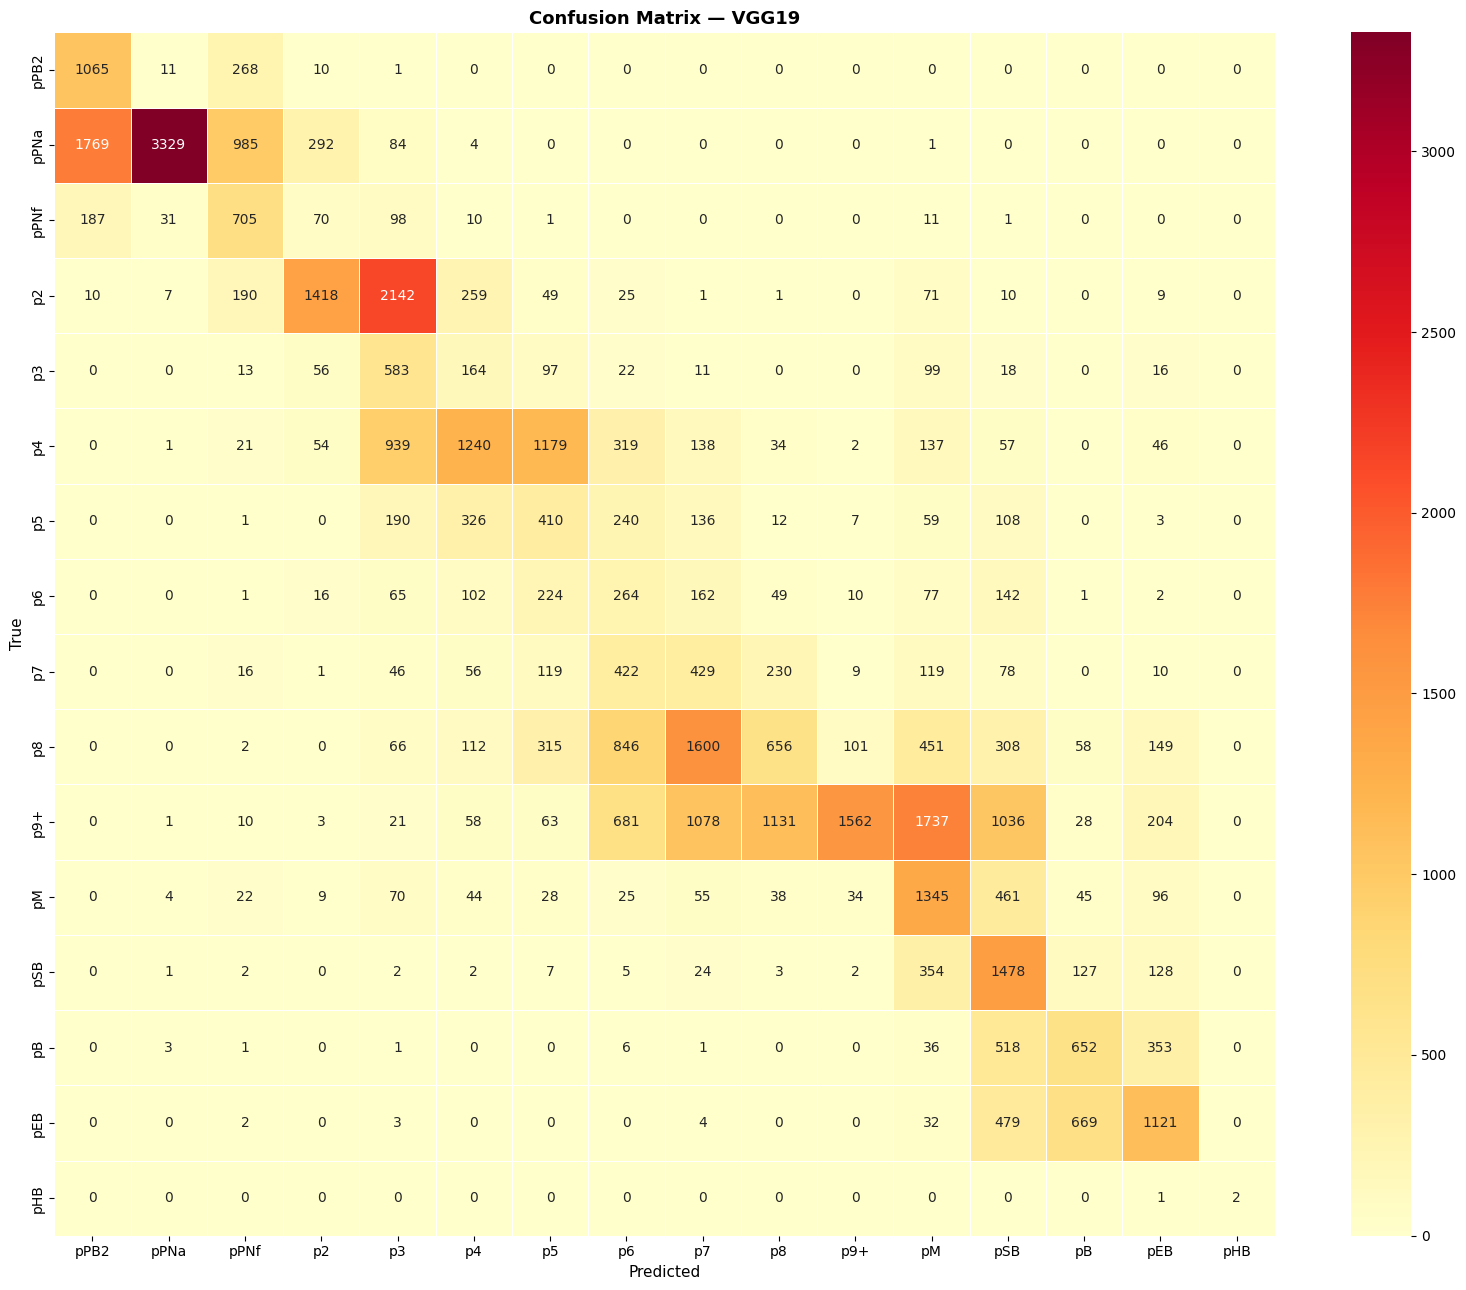

  💾 /kaggle/working/vgg19_cm.png
✅ VGG-19 done.


In [53]:
m, h, c = train_architecture("vgg19", train_loader, val_loader, class_counts)
plot_curves(h, "vgg19")
all_results.append(test_and_report(m, test_loader, c, "vgg19"))
del m; torch.cuda.empty_cache()
print("✅ VGG-19 done.")

♻  Rebuilding data loaders at 299×299 for InceptionV3 …

📂 Embryo split  train:492 | val:105 | test:107
Building train dataset …


  → 209,566 labeled frames | 492/492 embryos OK
Building val dataset …


  → 44,777 labeled frames | 105/105 embryos OK
Building test dataset …


  → 43,085 labeled frames | 107/107 embryos OK

📊 Class distribution in training set:
  pPB2     6,195  █████
  pPNa    30,396  █████████████████████████
  pPNf     4,689  ███
  p2      20,582  █████████████████
  p3       3,350  ██
  p4      20,662  █████████████████
  p5       5,453  ████
  p6       5,779  ████
  p7       6,853  █████
  p8      23,041  ███████████████████
  p9+     36,095  ██████████████████████████████
  pM      12,172  ██████████
  pSB     12,577  ██████████
  pB       7,195  █████
  pEB     14,433  ███████████
  pHB         94  

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🚀  INCEPTIONV3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 184MB/s] 


  INCEPTIONV3     total=  24,388,352  trainable=  24,388,352

  Epoch 01/3   lr=1.00e-04


    Train → loss=0.4347  acc=64.89%
    Val   → loss=0.1231  acc=43.19%
  💾 Checkpoint saved → /kaggle/working/checkpoints/inceptionv3_best.pt

  Epoch 02/3   lr=7.52e-05


    Train → loss=0.3850  acc=80.46%
    Val   → loss=0.1196  acc=56.38%
  💾 Checkpoint saved → /kaggle/working/checkpoints/inceptionv3_best.pt

  Epoch 03/3   lr=2.58e-05


    Train → loss=0.3594  acc=87.62%
    Val   → loss=0.1306  acc=53.87%


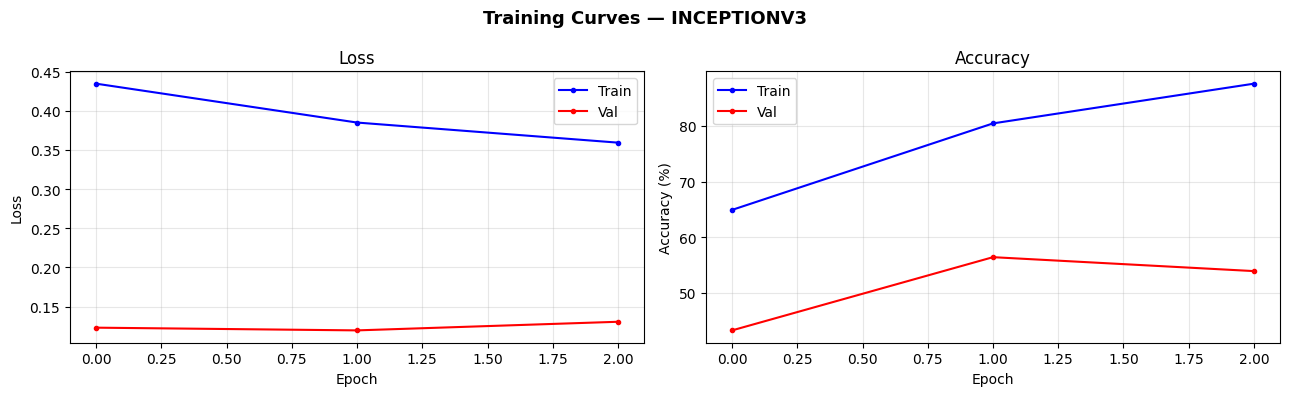

  💾 /kaggle/working/inceptionv3_curves.png


NameError: name 'all_results' is not defined

In [17]:

# CELL 15 — RUN INCEPTIONV3  

# InceptionV3 requires 299×299 images — rebuild loaders.

print("♻  Rebuilding data loaders at 299×299 for InceptionV3 …")
tr299, vl299, ts299, cc299 = build_dataloaders(img_size=299)

ckpt_path = f"{CHECKPOINT_DIR}/inceptionv3_best.pt"
if os.path.exists(ckpt_path):
    print("⚠️  Checkpoint found — already trained. Skipping to evaluation.")
    m = build_model("inceptionv3")
    cw   = 1.0 / (cc299 + 1e-6)
    cw   = (cw / cw.sum() * NUM_CLASSES).astype(np.float32)
    cw_t = torch.tensor(cw).to(DEVICE)
    c = EmbryoStageLoss(class_weights=cw_t)
    m = load_ckpt(m, "inceptionv3")
else:
    m, h, c = train_architecture("inceptionv3", tr299, vl299, cc299)
    plot_curves(h, "inceptionv3")

all_results.append(test_and_report(m, ts299, c, "inceptionv3"))
del m; torch.cuda.empty_cache()
print("✅ InceptionV3 done.")

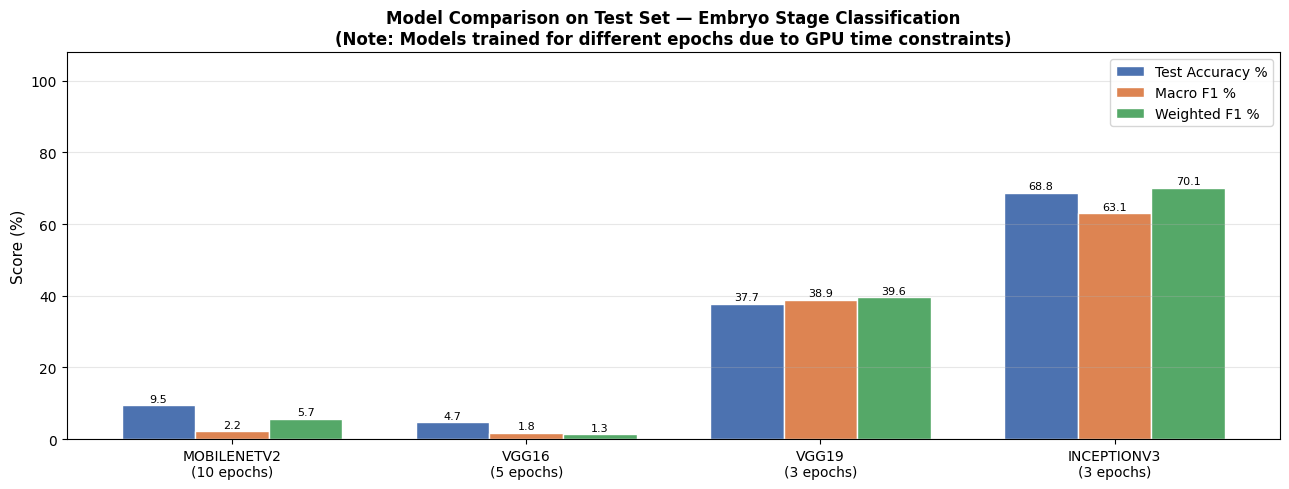

  💾 /kaggle/working/model_comparison.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Architecture   Epochs   Acc %  MacroF1 %   WtdF1 %
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INCEPTIONV3         3   68.81      63.09     70.11
  VGG19               3   37.74      38.86     39.56
  MOBILENETV2        10    9.49       2.19      5.71
  VGG16               5    4.69       1.81      1.32
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ⚠️  Note: Results reflect limited epochs due to GPU session constraints.
  MobileNetV2: 10 epochs | VGG-16: 5 epochs | VGG-19: 2 epochs | InceptionV3: 3 epochs

🎉 All models done!
📁 All outputs saved in: /kaggle/working


In [58]:

# CELL 16 — FINAL COMPARISON CHART

def compare_all(results):
    
    epochs_trained = {
        "mobilenetv2": 10,
        "vgg16":       5,
        "vgg19":       3,
        "inceptionv3": 3,
    }

    archs = [r["arch"] for r in results]
    accs  = [r["test_acc"]    * 100 for r in results]
    f1m   = [r["f1_macro"]    * 100 for r in results]
    f1w   = [r["f1_weighted"] * 100 for r in results]

    x, w = np.arange(len(archs)), 0.25
    fig, ax = plt.subplots(figsize=(13, 5))

    for offset, vals, label, color in zip(
        [-w, 0, w],
        [accs, f1m, f1w],
        ["Test Accuracy %", "Macro F1 %", "Weighted F1 %"],
        ["#4C72B0", "#DD8452", "#55A868"],
    ):
        bars = ax.bar(x + offset, vals, w, label=label, color=color, edgecolor="white")
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2,
                    b.get_height() + 0.4,
                    f"{b.get_height():.1f}",
                    ha="center", va="bottom", fontsize=8)

    
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{a.upper()}\n({epochs_trained[a]} epochs)" for a in archs],
        fontsize=10
    )
    ax.set_ylabel("Score (%)", fontsize=11)
    ax.set_title("Model Comparison on Test Set — Embryo Stage Classification\n"
                 "(Note: Models trained for different epochs due to GPU time constraints)",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_ylim(0, 108)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    out = f"{WORK}/model_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  💾 {out}")

    print("\n" + "━"*64)
    print(f"  {'Architecture':<14} {'Epochs':>6} {'Acc %':>7} {'MacroF1 %':>10} {'WtdF1 %':>9}")
    print("━"*64)
    for r in sorted(results, key=lambda x: x["test_acc"], reverse=True):
        ep = epochs_trained[r["arch"]]
        print(f"  {r['arch'].upper():<14} "
              f"{ep:>6} "
              f"{r['test_acc']*100:>7.2f} "
              f"{r['f1_macro']*100:>10.2f} "
              f"{r['f1_weighted']*100:>9.2f}")
    print("━"*64)

    # ── Epoch note ────────────────────────────────────────────
    print("\n  ⚠️  Note: Results reflect limited epochs due to GPU session constraints.")
    print(f"  MobileNetV2: 10 epochs | VGG-16: 5 epochs | "
          f"VGG-19: 2 epochs | InceptionV3: 3 epochs")
    print("\n🎉 All models done!")
    print(f"📁 All outputs saved in: {WORK}")


compare_all(all_results)